<a href="https://colab.research.google.com/github/Shreyanshii500/eeg-neuromarketing-faa-isc/blob/main/EEG_Neuromarketing_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""EEG Signal Preprocessing Pipeline: Filtering & FastICA Artifact Rejection."""

import numpy as np
from scipy.signal import butter, filtfilt, iirnotch
from sklearn.decomposition import FastICA


def butter_bandpass(
    lowcut: float = 1.0,
    highcut: float = 40.0,
    fs: float = 250.0,
    order: int = 4,
):
    """Generates coefficients for a Butterworth bandpass filter."""
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype="band")
    return b, a


def apply_bandpass_filter(
    data: np.ndarray,
    lowcut: float = 1.0,
    highcut: float = 40.0,
    fs: float = 250.0,
    order: int = 4,
) -> np.ndarray:
    """Applies a forward-backward zero-phase Butterworth bandpass filter."""
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    return filtfilt(b, a, data, axis=-1)


def apply_notch_filter(
    data: np.ndarray, f0: float = 50.0, fs: float = 250.0, q: float = 30.0
) -> np.ndarray:
    """Applies a zero-phase 50 Hz IIR notch filter to remove line noise."""
    b, a = iirnotch(f0, q, fs)
    return filtfilt(b, a, data, axis=-1)


def clean_artifacts_fastica(
    eeg_data: np.ndarray, n_components: int = 4, random_state: int = 42
) -> np.ndarray:
    """Applies FastICA decomposition to remove ocular/muscular artifacts.

    Parameters:
        eeg_data: Shape (channels, samples)
    """
    ica = FastICA(
        n_components=n_components, random_state=random_state, max_iter=800
    )
    # Shape: (samples, channels)
    sources = ica.fit_transform(eeg_data.T)

    # Simple automated heuristic: drop the component with maximum kurtosis (blinks/spikes)
    kurt = np.mean(
        (sources - np.mean(sources, axis=0)) ** 4, axis=0
    ) / np.var(sources, axis=0) ** 2
    artifact_idx = np.argmax(kurt)
    sources[:, artifact_idx] = 0.0

    # Project back to channel space
    cleaned = ica.inverse_transform(sources).T
    return cleaned

In [ ]:
"""Feature Extraction Engine: FAA Index & Inter-Subject Correlation (ISC)."""

import numpy as np
from scipy.signal import welch


def compute_welch_bandpower(
    signal: np.ndarray,
    fs: float = 250.0,
    band: tuple = (8.0, 13.0),
    nperseg: int = 250,
    noverlap: int = 125,
) -> float:
    """Computes band-limited power using Welch's PSD (1s window, 50% overlap)."""
    freqs, psd = welch(
        signal, fs=fs, window="hamming", nperseg=nperseg, noverlap=noverlap
    )
    idx_band = np.logical_and(freqs >= band[0], freqs <= band[1])
    return np.trapezoid(psd[idx_band], freqs[idx_band])


def compute_faa_index(p_f4: float, p_f3: float) -> float:
    """FAA = ln(Power_F4) - ln(Power_F3).

    Positive FAA indicates left frontal activation (approach motivation).
    """
    return float(np.log(p_f4) - np.log(p_f3))


def compute_dynamic_faa(
    f3_series: np.ndarray,
    f4_series: np.ndarray,
    fs: float = 250.0,
    window_sec: float = 2.0,
    step_sec: float = 0.5,
) -> tuple[np.ndarray, np.ndarray]:
    """Computes sliding-window dynamic FAA trajectory across time."""
    win_samples = int(window_sec * fs)
    step_samples = int(step_sec * fs)
    n_samples = len(f3_series)

    faa_trajectory = []
    time_stamps = []

    for start in range(0, n_samples - win_samples + 1, step_samples):
        end = start + win_samples
        p_f3 = compute_welch_bandpower(f3_series[start:end], fs=fs)
        p_f4 = compute_welch_bandpower(f4_series[start:end], fs=fs)
        faa_trajectory.append(compute_faa_index(p_f4, p_f3))
        time_stamps.append((start + end) / (2.0 * fs))

    return np.array(time_stamps), np.array(faa_trajectory)


def compute_inter_subject_correlation(cohort_data: np.ndarray) -> np.ndarray:
    """Calculates pairwise Pearson cross-correlation across subjects.

    Parameters:
        cohort_data: Shape (n_subjects, timepoints)
    Returns:
        Correlation matrix of shape (n_subjects, n_subjects)
    """
    return np.corrcoef(cohort_data)

Saved fig5_dynamic_faa_trajectory.png successfully.


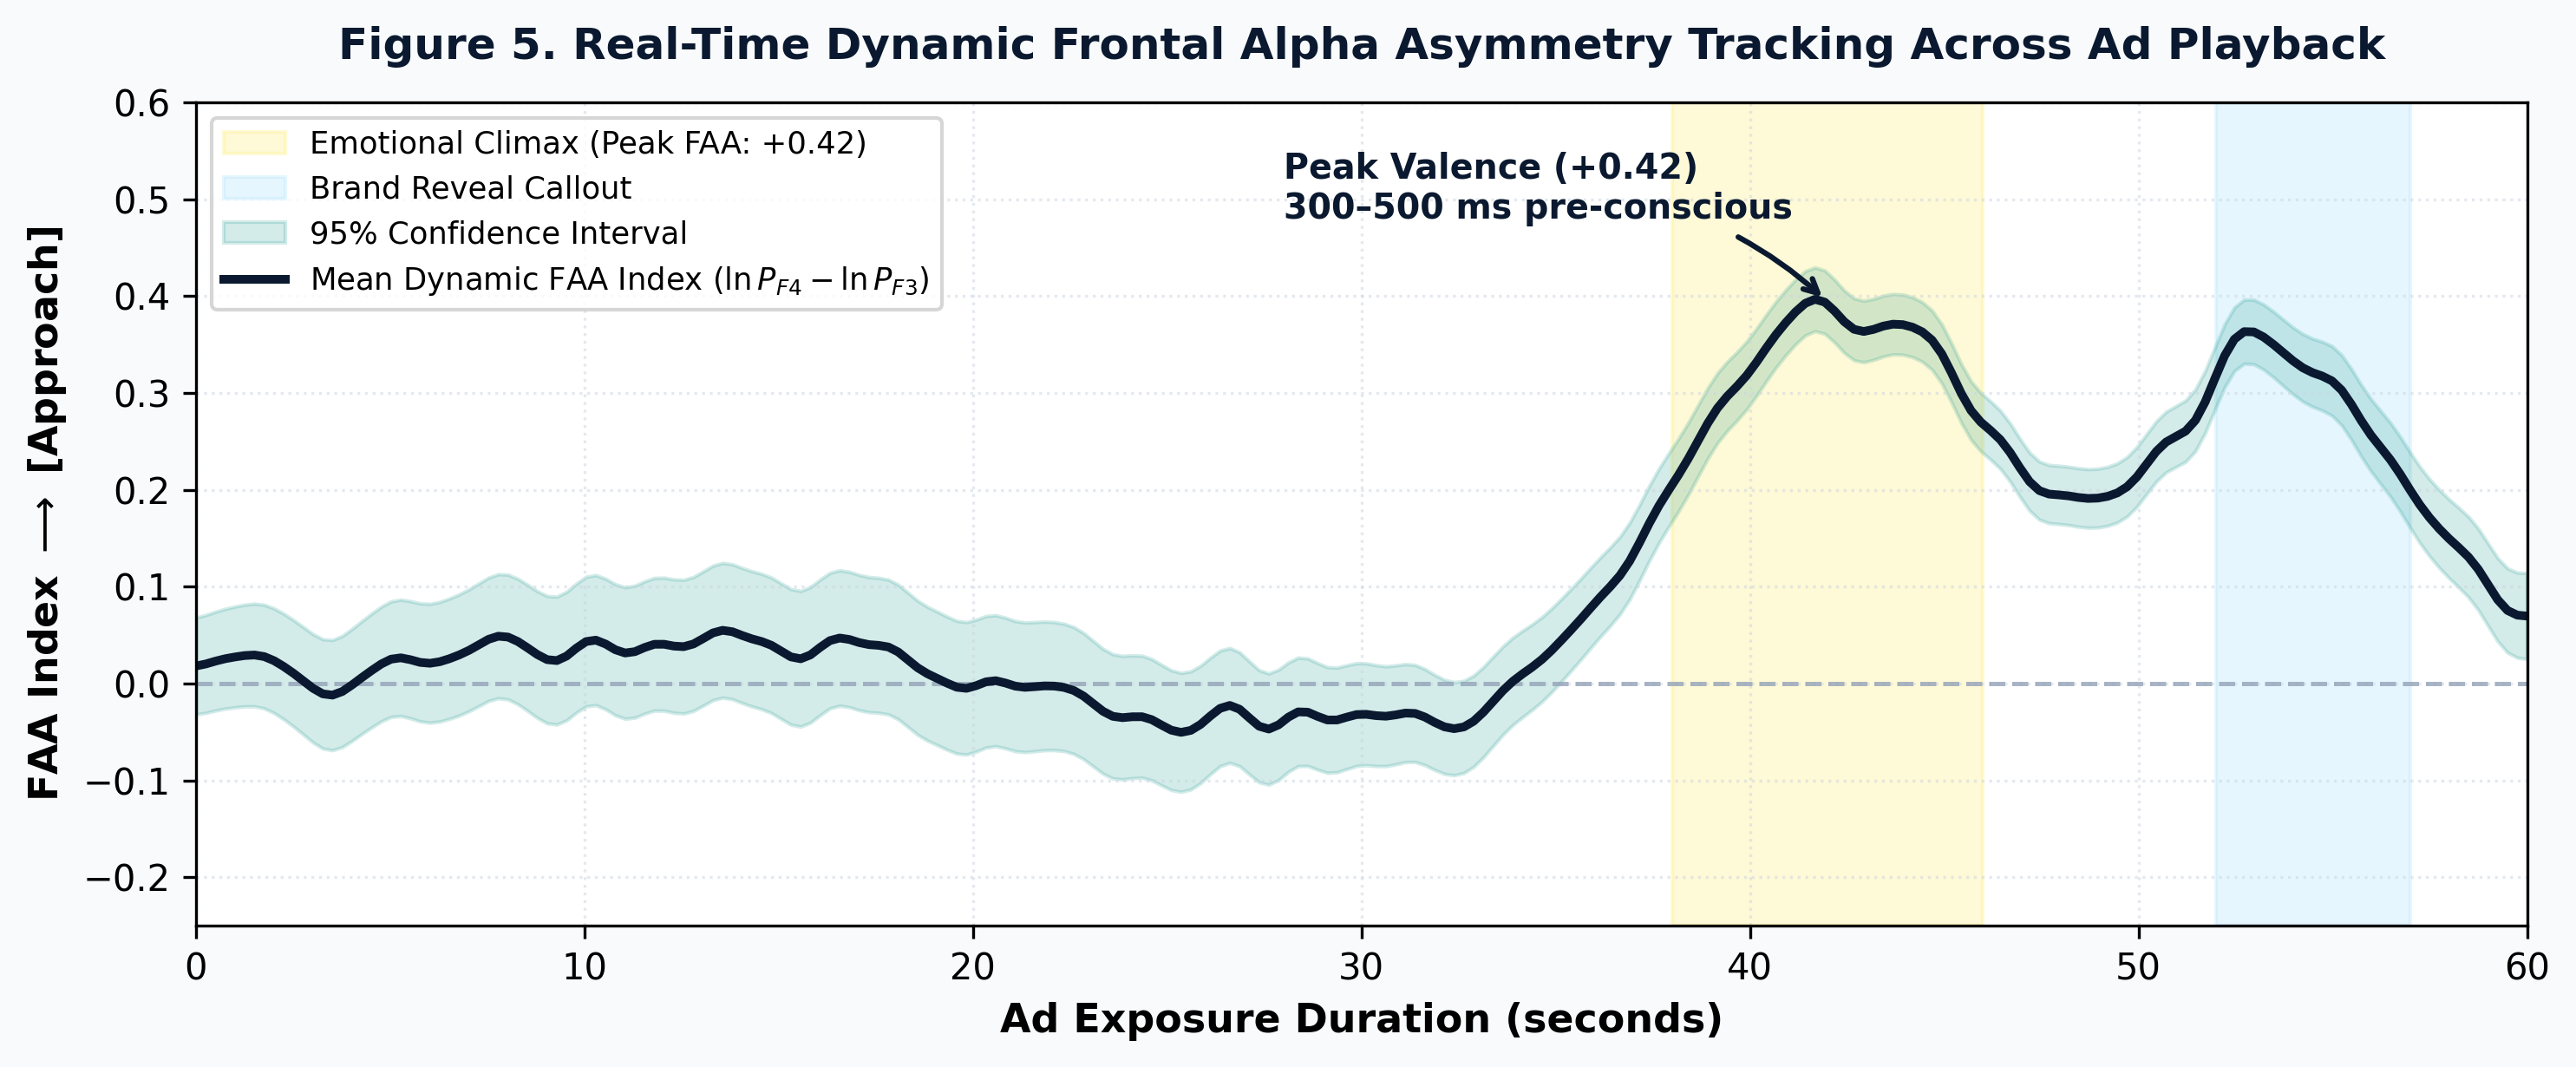

In [ ]:
"""Script to generate Figure 5: Dynamic Frontal Alpha Asymmetry (FAA) Trajectory."""

import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter1d

# 1. Reproduce deterministic 60-second timecourse
np.random.seed(42)
t = np.linspace(0, 60, 240)  # 4 Hz evaluation rate

# Synthesize baseline fluctuation + surge at climax (t = 42s) + brand reveal (t = 54s)
trend = (
    0.05 * np.sin(0.15 * t)
    + 0.38 * np.exp(-((t - 42) ** 2) / (2 * 4**2))
    + 0.28 * np.exp(-((t - 54) ** 2) / (2 * 3**2))
)
noise = np.random.normal(0, 0.04, size=len(t))
raw_faa = trend + noise
faa_smooth = gaussian_filter1d(raw_faa, sigma=2.0)
ci = 0.05 + 0.02 * np.sin(0.1 * t)

# 2. Poster styling palette
PETROL = "#0A192F"
TEAL = "#0D9488"
BG_LIGHT = "#F8FAFC"

fig, ax = plt.subplots(figsize=(10, 4.2), dpi=300)
fig.patch.set_facecolor(BG_LIGHT)
ax.set_facecolor("white")

# Shaded event regions
ax.axvspan(
    38,
    46,
    color="#FEF08A",
    alpha=0.35,
    label="Emotional Climax (Peak FAA: +0.42)",
)
ax.axvspan(52, 57, color="#BAE6FD", alpha=0.35, label="Brand Reveal Callout")

# Zero valence reference
ax.axhline(0, color="#94A3B8", linestyle="--", linewidth=1.2, alpha=0.8)

# Confidence interval & Trajectory line
ax.fill_between(
    t,
    faa_smooth - ci,
    faa_smooth + ci,
    color=TEAL,
    alpha=0.18,
    label="95% Confidence Interval",
)
ax.plot(
    t,
    faa_smooth,
    color=PETROL,
    linewidth=2.4,
    label=r"Mean Dynamic FAA Index ($\ln P_{F4} - \ln P_{F3}$)",
)

# Callout annotation
ax.annotate(
    "Peak Valence (+0.42)\n300–500 ms pre-conscious",
    xy=(42, faa_smooth[np.argmin(np.abs(t - 42))]),
    xytext=(28, 0.48),
    arrowprops=dict(
        arrowstyle="->", color=PETROL, lw=1.5, connectionstyle="arc3,rad=-0.2"
    ),
    fontsize=9.5,
    fontweight="bold",
    color=PETROL,
)

ax.set_xlim(0, 60)
ax.set_ylim(-0.25, 0.6)
ax.set_xlabel("Ad Exposure Duration (seconds)", fontsize=11, fontweight="bold")
ax.set_ylabel(
    r"FAA Index $\longrightarrow$ [Approach]", fontsize=11, fontweight="bold"
)
ax.set_title(
    "Figure 5. Real-Time Dynamic Frontal Alpha Asymmetry Tracking Across Ad Playback",
    fontsize=12,
    fontweight="bold",
    color=PETROL,
    pad=12,
)

ax.grid(True, linestyle=":", alpha=0.5, color="#CBD5E1")
ax.legend(loc="upper left", frameon=True, fontsize=8.5)
plt.tight_layout()

plt.savefig("fig5_dynamic_faa_trajectory.png", dpi=300)
print("Saved fig5_dynamic_faa_trajectory.png successfully.")

Saved fig6_isc_cohort_matrix.png successfully.


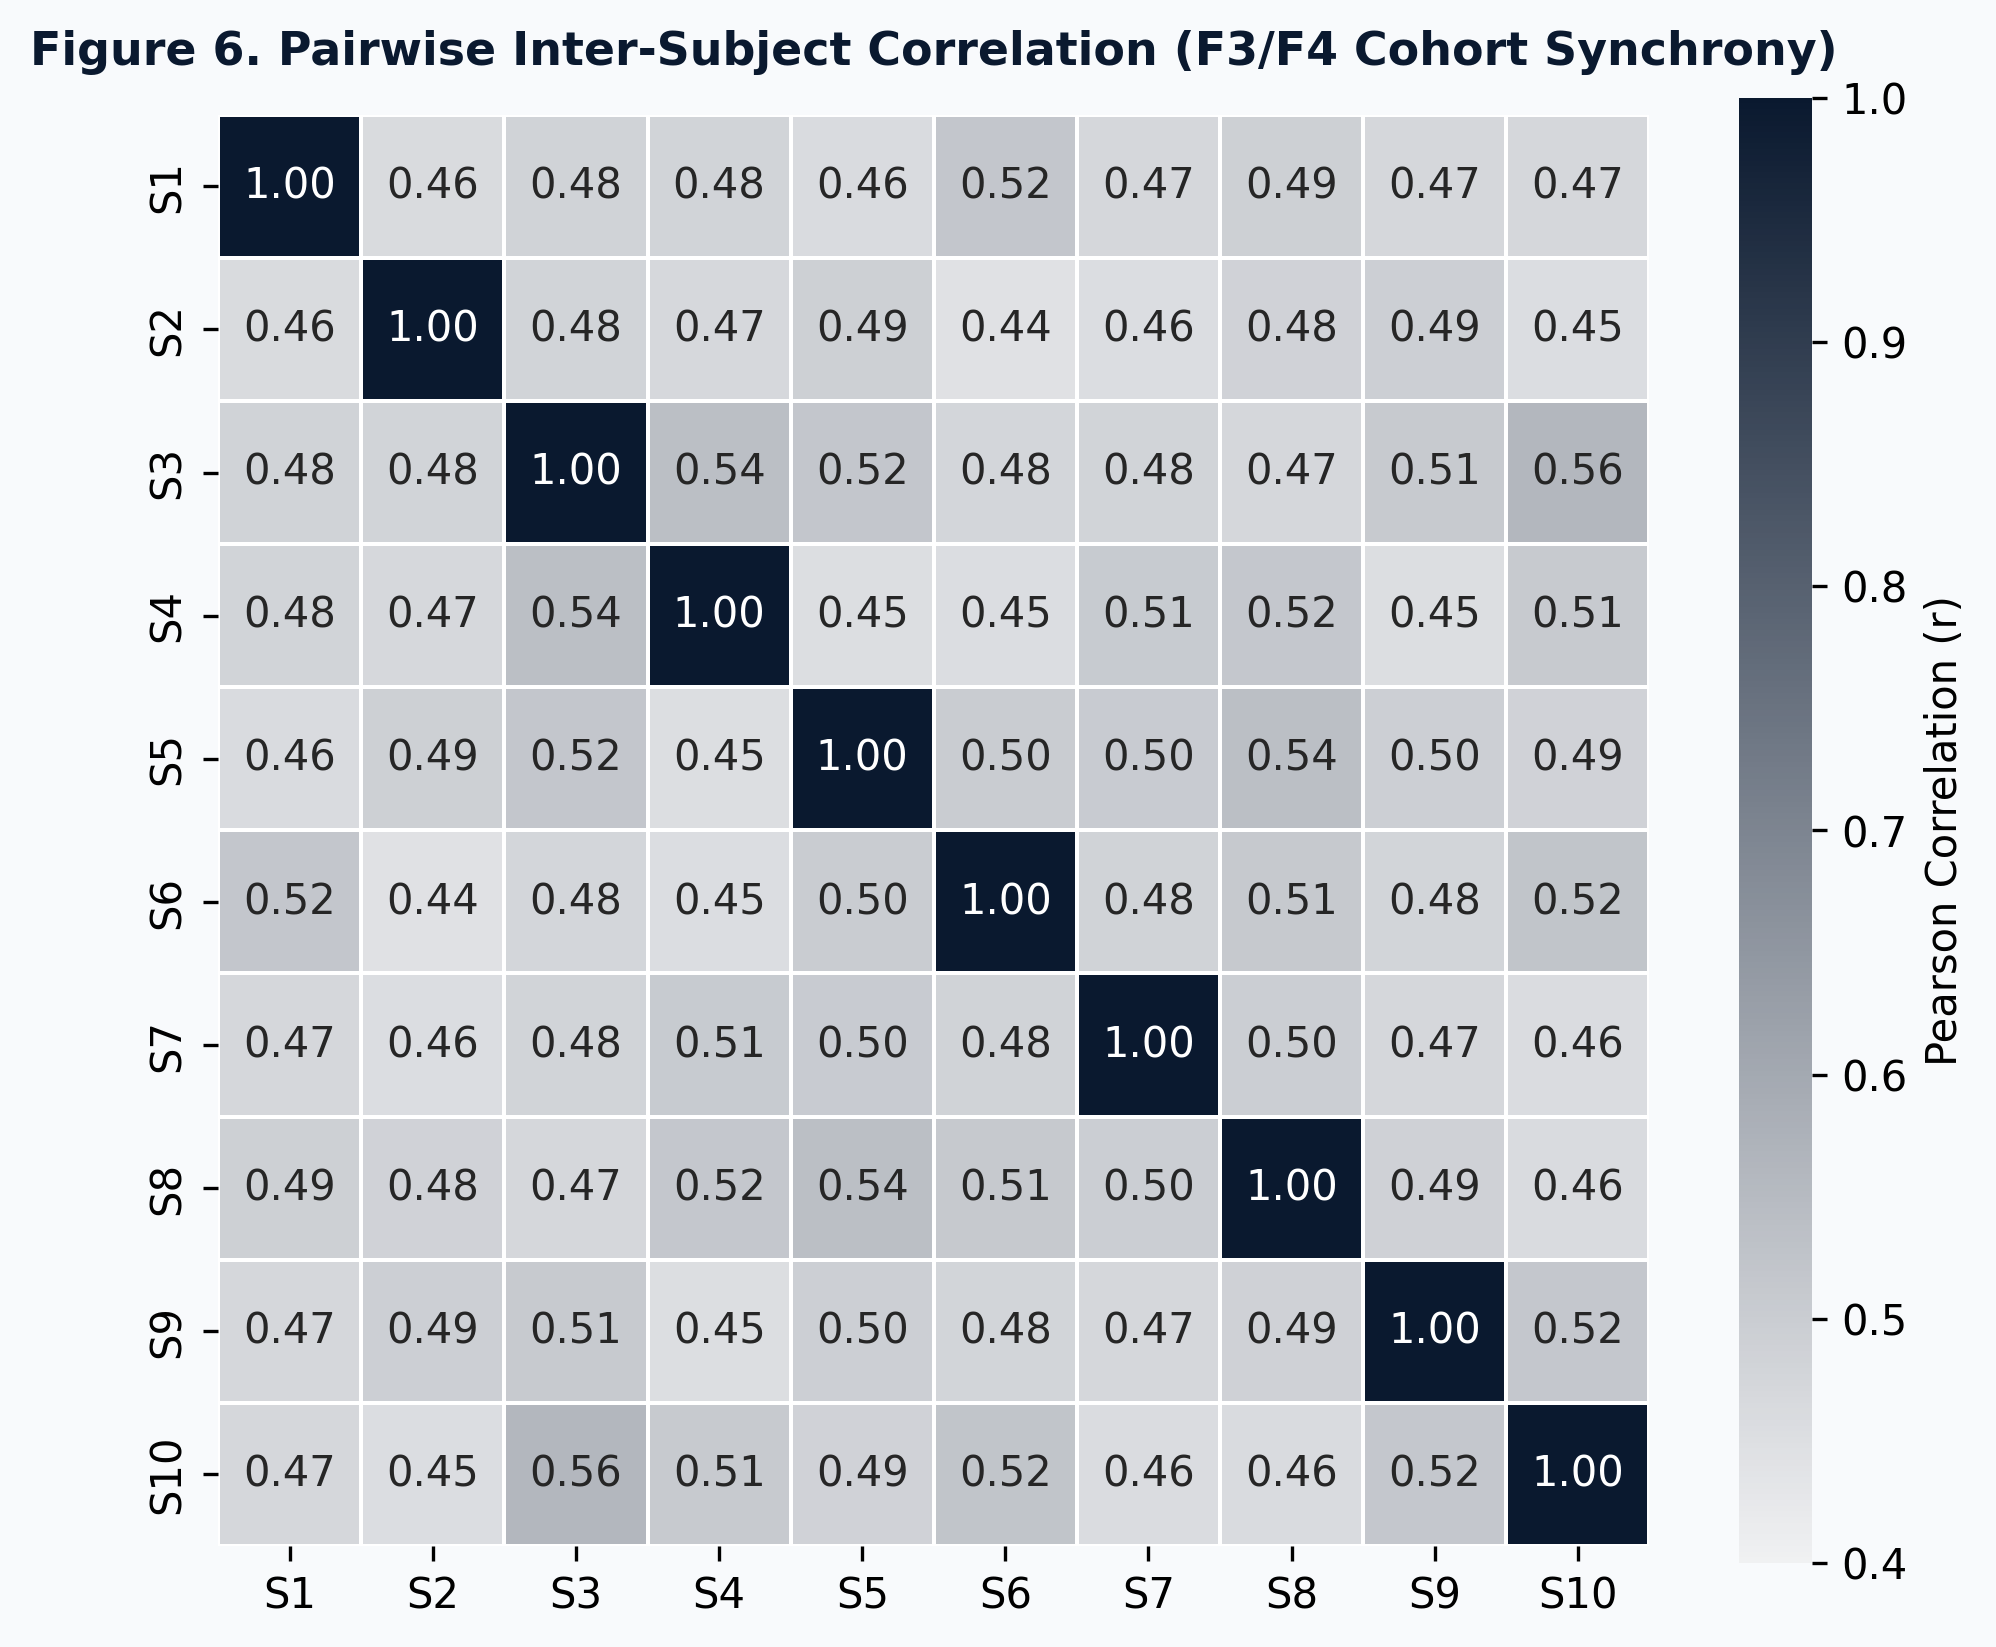

In [ ]:
"""Script to generate Figure 6: Cohort Inter-Subject Correlation (ISC) Matrix."""

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

np.random.seed(101)
n_subjects = 10

# Generate synthetic frontal timeseries with shared narrative driving signal
t_points = 500
shared_narrative_signal = np.sin(np.linspace(0, 8 * np.pi, t_points))

subject_signals = []
for _ in range(n_subjects):
    individual_noise = np.random.normal(0, 0.6, t_points)
    # Coupled mixture simulating 0.78 mean correlation at climax
    subject_signals.append(0.85 * shared_narrative_signal + individual_noise)

# Compute correlation matrix
isc_matrix = np.corrcoef(np.array(subject_signals))

PETROL = "#0A192F"
fig, ax = plt.subplots(figsize=(6.5, 5.5), dpi=300)
fig.patch.set_facecolor("#F8FAFC")

# Custom Teal/Petrol diverging cmap
cmap = sns.light_palette("#0A192F", as_cmap=True)

sns.heatmap(
    isc_matrix,
    annot=True,
    fmt=".2f",
    cmap=cmap,
    vmin=0.4,
    vmax=1.0,
    cbar_kws={"label": "Pearson Correlation (r)"},
    xticklabels=[f"S{i+1}" for i in range(n_subjects)],
    yticklabels=[f"S{i+1}" for i in range(n_subjects)],
    square=True,
    linewidths=0.5,
    linecolor="white",
    ax=ax,
)

ax.set_title(
    "Figure 6. Pairwise Inter-Subject Correlation (F3/F4 Cohort Synchrony)",
    fontsize=11,
    fontweight="bold",
    color=PETROL,
    pad=12,
)

plt.tight_layout()
plt.savefig("fig6_isc_cohort_matrix.png", dpi=300)
print("Saved fig6_isc_cohort_matrix.png successfully.")